# `criticality.ipynb`: compute dynamical exponent

In [1]:
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from scipy.stats import linregress

from utils.modelIO import *
from utils.phases import *

initialize

In [2]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
BIO_SIM_PATH = Path('results/eml/bio_T_fine/')
RAND_SIM_PATH = Path('results/eml/rand_T_fine/')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
temperatures = jnp.linspace(1.0, 2.5, 151)

load data and compute correlation times

In [3]:
bio_fns = [BIO_SIM_PATH.joinpath('bio_mT_{:03}_xs.npy'.format((100*T).astype(int))) for T in temperatures]
rand_fns = [RAND_SIM_PATH.joinpath('rand_mT_{:03}_xs.npy'.format((100*T).astype(int))) for T in temperatures]

bio_t_corr = jnp.array([get_ac_time(jnp.load(bio_fn), N) for bio_fn in bio_fns])
rand_t_corr = jnp.array([get_ac_time(jnp.load(rand_fn), N) for rand_fn in rand_fns])

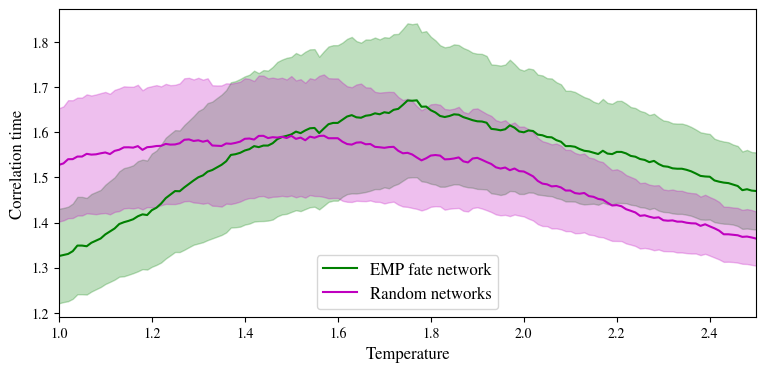

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temperatures, bio_t_corr.T[0], c='g', label='EMP fate network')
ax.plot(temperatures, rand_t_corr.T[0], c='m', label='Random networks')
ax.fill_between(temperatures, bio_t_corr.T[0]-2*bio_t_corr.T[1], bio_t_corr.T[0]+2*bio_t_corr.T[1],
                color='g', alpha=0.25)
ax.fill_between(temperatures, rand_t_corr.T[0]-2*rand_t_corr.T[1], rand_t_corr.T[0]+2*rand_t_corr.T[1],
                color='m', alpha=0.25)
ax.set_xlim(1.0, 2.5)
ax.legend(loc='lower center', fontsize=12)
ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel(r'Correlation time', fontsize=12)
plt.savefig(FIG_SAVE_PATH.joinpath('correlation_times.pdf'), bbox_inches='tight')

Compute critical temperatures

In [5]:
bio_Tg = temperatures[jnp.argmax(bio_t_corr.T[0])]
rand_Tg = temperatures[jnp.argmax(rand_t_corr.T[0])]

print('EMP fate network critical temperature: {:.2f}'.format(bio_Tg))
print('Random network critical temperature: {:.2f}'.format(rand_Tg))

EMP fate network critical temperature: 1.77
Random network critical temperature: 1.57


Compute critical exponents

In [6]:
# paths to simulations at critical temperature
bio_Tg_path = BIO_SIM_PATH.joinpath('bio_mT_{:03}_xs.npy'.format((100*bio_Tg).astype(int)))
rand_Tg_path = RAND_SIM_PATH.joinpath('rand_mT_{:03}_xs.npy'.format((100*rand_Tg).astype(int)))

# autocorrelations at critical temperature
bio_Tg_xs = jnp.load(bio_Tg_path)
bio_Tg_C = get_avg_autocorrelation(bio_Tg_xs, N)
del bio_Tg_xs

rand_Tg_xs = jnp.load(rand_Tg_path)
rand_Tg_C = get_avg_autocorrelation(rand_Tg_xs, N)
del rand_Tg_xs

In [7]:
ts = jnp.arange(bio_Tg_C.shape[0])

bio_mask = (bio_Tg_C > 0) & (ts > 0)
bio_negx, _, bio_r, _, bio_x_se = linregress(jnp.log(ts)[bio_mask], jnp.log(bio_Tg_C)[bio_mask])

rand_mask = (rand_Tg_C > 0) & (ts > 0)
rand_negx, _, rand_r, _, rand_x_se = linregress(jnp.log(ts)[rand_mask], jnp.log(rand_Tg_C)[rand_mask])

In [8]:
print('EMP fate network: x = {:.2f} pm {:.2f}, r^2 = {:.2f}'.format(-bio_negx, bio_x_se, bio_r**2))
print('Random networks: x = {:.2f} pm {:.2f}, r^2 = {:.2f}'.format(-rand_negx, rand_x_se, rand_r**2))

EMP fate network: x = 1.32 pm 0.07, r^2 = 0.68
Random networks: x = 0.78 pm 0.02, r^2 = 0.90
